# Viral sequence analysis from czid data
This notebook was created to analyze [CZID](https://czid.org) data from the same samples that will be analyzed through our shell scripts. The main idea behind this is to corroborate the results given by both methods and determine the viability of the designed pipeline. 

## Libraries.

In [137]:
# Libraries for data manupilation.

import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches




## Data load.
All sample information was downloaded.

In [138]:
base_path = Path.cwd().parents[1]

file_paths = {
    "PM3183": base_path / 'docs/czid_sequence_reports/PM3183_S6_923339_taxon_report.csv',
    "PM3051": base_path / 'docs/czid_sequence_reports/PM3051_S4_923337_taxon_report.csv',
    "PM3153": base_path / 'docs/czid_sequence_reports/PM3153_S5_923338_taxon_report.csv',
    "PM2622": base_path / 'docs/czid_sequence_reports/PM2622_S32_923335_taxon_report.csv',
    "PM2616": base_path / 'docs/czid_sequence_reports/PM2616_S22_923334_taxon_report.csv',
    "PM2601": base_path / 'docs/czid_sequence_reports/PM2601_S14_923333_taxon_report.csv',
    "PM2577": base_path / 'docs/czid_sequence_reports/PM2577_S13_923332_taxon_report.csv',
    "PM2539": base_path / 'docs/czid_sequence_reports/PM2539_S23_923331_taxon_report.csv',
    "PM2528": base_path / 'docs/czid_sequence_reports/PM2528_S2_923330_taxon_report.csv',
    "PM2524": base_path / 'docs/czid_sequence_reports/PM2524_S24_923329_taxon_report.csv',
    "PM2494": base_path / 'docs/czid_sequence_reports/PM2494_S26_923327_taxon_report.csv',
    "PM2469": base_path / 'docs/czid_sequence_reports/PM2469_S1_923325_taxon_report.csv',
}

samples = list(file_paths.keys())


    

In [139]:
# Dataframe modification and concatenation.

df_samples= []

for i in samples:
    # File read for each sample.
    file = file_paths[i]
    print(f"Sample: {i}")
    df=pd.read_csv(file)

    # Since the taxon category column is of our interest, we can filter every dataframe by the value of 'viruses' in the taxon category column to keep only the rows that have this value. 
    row_del = df['category'] == 'viruses' # If the taxId column has the value 'viruses' then we keep that row, otherwise we delete it.
    df = df[row_del].copy()

    # Add sample name to the dataframe.
    df['sample_name'] = i
    df_samples.append(df)


# Dataframe concatenation.
df_samples = pd.concat(df_samples, ignore_index=True)

display(df_samples)

Sample: PM3183
Sample: PM3051
Sample: PM3153
Sample: PM2622
Sample: PM2616
Sample: PM2601
Sample: PM2577
Sample: PM2539
Sample: PM2528
Sample: PM2524
Sample: PM2494
Sample: PM2469


,tax_id,tax_level,genus_tax_id,name,common_name,category,is_phage,agg_score,max_z_score,nt_z_score,...,nr_percent_identity,nr_alignment_length,nr_e_value,nr_bg_mean,nr_bg_stdev,nr_bg_mean_mass_normalized,nr_bg_stdev_mass_normalized,species_tax_ids,known_pathogen,sample_name
0,2842620,2,2842620,Culicidavirus,NaN,viruses,False,NaN,NaN,NaN,...,72.0000,25.0000,10^-5.79588,NaN,NaN,NaN,NaN,[2844040],0,PM3183
1,2844040,1,2842620,Culicidavirus quitotaense,NaN,viruses,False,NaN,NaN,NaN,...,72.0000,25.0000,10^-5.79588,NaN,NaN,NaN,NaN,NaN,0,PM3183
2,1884455,2,1884455,Anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,83.6500,24.5000,10^-5.18245,NaN,NaN,NaN,NaN,[2980617],0,PM3183
3,2980617,1,1884455,Joensuu anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,83.6500,24.5000,10^-5.18245,NaN,NaN,NaN,NaN,NaN,0,PM3183
4,1307798,2,1307798,Negevirus,NaN,viruses,False,NaN,NaN,NaN,...,97.2333,24.0000,10^-6.41519,NaN,NaN,NaN,NaN,[2651953],0,PM3183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1272,2952019,1,-200012058,XiangYun picorna-like virus 2,NaN,viruses,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,PM2469
1273,-200186665,2,-200186665,non-genus-specific reads in family Metaviridae,NaN,viruses,False,NaN,NaN,NaN,...,85.7571,24.1429,10^-4.54861,NaN,NaN,NaN,NaN,[2689361],0,PM2469
1274,2689361,1,-200186665,Chibugado virus,NaN,viruses,False,NaN,NaN,NaN,...,85.7571,24.1429,10^-4.54861,NaN,NaN,NaN,NaN,NaN,0,PM2469
1275,-200232795,2,-200232795,non-genus-specific reads in family Dicistrovir...,NaN,viruses,False,NaN,NaN,NaN,...,100.0000,24.0000,10^-6.50585,NaN,NaN,NaN,NaN,[2789442],0,PM2469


In [140]:
# Dataframe cleaning and manipulation.
df_samples = df_samples.drop(columns= ['agg_score',	'max_z_score',	'nt_z_score', 'nt_bg_mean',	'nt_bg_stdev',	
                                       'nt_bg_mean_mass_normalized',	'nt_bg_stdev_mass_normalized',	'nr_z_score', 
                                       'nr_bg_mean',	'nr_bg_stdev',	'nr_bg_mean_mass_normalized',	'nr_bg_stdev_mass_normalized'])
display(df_samples)



,tax_id,tax_level,genus_tax_id,name,common_name,category,is_phage,nt_rpm,nt_count,nt_contigs,...,nr_rpm,nr_count,nr_contigs,nr_contig_r,nr_percent_identity,nr_alignment_length,nr_e_value,species_tax_ids,known_pathogen,sample_name
0,2842620,2,2842620,Culicidavirus,NaN,viruses,False,NaN,NaN,NaN,...,0.119115,1.0,NaN,NaN,72.0000,25.0000,10^-5.79588,[2844040],0,PM3183
1,2844040,1,2842620,Culicidavirus quitotaense,NaN,viruses,False,NaN,NaN,NaN,...,0.119115,1.0,NaN,NaN,72.0000,25.0000,10^-5.79588,NaN,0,PM3183
2,1884455,2,1884455,Anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,0.238229,2.0,NaN,NaN,83.6500,24.5000,10^-5.18245,[2980617],0,PM3183
3,2980617,1,1884455,Joensuu anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,0.238229,2.0,NaN,NaN,83.6500,24.5000,10^-5.18245,NaN,0,PM3183
4,1307798,2,1307798,Negevirus,NaN,viruses,False,0.238229,2.0,NaN,...,0.357344,3.0,NaN,NaN,97.2333,24.0000,10^-6.41519,[2651953],0,PM3183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1272,2952019,1,-200012058,XiangYun picorna-like virus 2,NaN,viruses,False,21.134359,184.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,PM2469
1273,-200186665,2,-200186665,non-genus-specific reads in family Metaviridae,NaN,viruses,False,NaN,NaN,NaN,...,0.804025,7.0,NaN,NaN,85.7571,24.1429,10^-4.54861,[2689361],0,PM2469
1274,2689361,1,-200186665,Chibugado virus,NaN,viruses,False,NaN,NaN,NaN,...,0.804025,7.0,NaN,NaN,85.7571,24.1429,10^-4.54861,NaN,0,PM2469
1275,-200232795,2,-200232795,non-genus-specific reads in family Dicistrovir...,NaN,viruses,False,NaN,NaN,NaN,...,0.114861,1.0,NaN,NaN,100.0000,24.0000,10^-6.50585,[2789442],0,PM2469


In [141]:

# Metadata by sample. This includes sample name, locality, mosquito species, ecological classification
df_metadata = pd.read_csv(base_path / 'docs/czid_sequence_reports/sample_overviews.csv')

# Metadata cleaning and manipulation.

# Sample name modification to match sample names in the sequence report dataframe.
df_metadata["sample_name"] = df_metadata["sample_name"].str.replace(r"_S\d{1,2}", "", regex=True)

# Variable renaming.
df_metadata["state"] = df_metadata["collection_location"].str.strip()

# Column dropping.
df_metadata = df_metadata.drop(columns= ['upload_date', 'notes', 'insert_size_median',	'insert_size_mode',	'insert_size_median_absolute_deviation',	
                                         'insert_size_min',	'insert_size_max',	'insert_size_mean',	'insert_size_standard_deviation',	'insert_size_read_pairs', 'collection_location'])


# Sampling site
site = {
    "PM2469": "Nuevo_Conhuas",
    "PM2486": "Calkini",
    "PM2494": "Calkini",
    "PM2497": "Calkini",
    "PM2524": "Nuevo_Conhuas",
    "PM2528": "Nuevo_Conhuas",
    "PM2539": "Merida",
    "PM2577": "Nuevo_Conhuas",
    "PM2601": "San_Simon",
    "PM2616": "San_Simon",
    "PM2622": "San_Simon",
    "PM3050": "Palizada",
    "PM3051": "Palizada",
    "PM3153": "Caobas",
    "PM3183": "Caobas"
}

df_metadata["site"] = df_metadata["sample_name"].map(site)

# Sample ecological classification based on the locality of collection.
habitat = {
    "PM2469": "conservado",
    "PM2486": "diversificado",
    "PM2494": "diversificado",
    "PM2497": "diversificado",
    "PM2524": "conservado",
    "PM2528": "conservado",
    "PM2539": "urbano",
    "PM2577": "conservado",
    "PM2601": "conservado",
    "PM2616": "conservado",
    "PM2622": "conservado",
    "PM3050": "rural",
    "PM3051": "rural",
    "PM3153": "diversificado",
    "PM3183": "diversificado"
}

df_metadata["habitat"] = df_metadata["sample_name"].map(habitat)

# Mosquito species by sample
species = {
    "PM2469": "aedes_serratus",
    "PM2486": "aedes_taeniorhynchus",
    "PM2494": "aedes_taeniorhynchus",
    "PM2497": "aedes_taeniorhynchus",
    "PM2524": "aedes_taeniorhynchus",
    "PM2528": "aedes_serratus",
    "PM2539": "aedes_taeniorhynchus",
    "PM2577": "aedes_taeniorhynchus",
    "PM2601": "aedes_taeniorhynchus",
    "PM2616": "aedes_taeniorhynchus",
    "PM2622": "aedes_taeniorhynchus",
    "PM3050": "aedes_serratus",
    "PM3051": "aedes_serratus",
    "PM3153": "aedes_serratus",
    "PM3183": "aedes_serratus"
}

df_metadata["species"] = df_metadata["sample_name"].map(species)

display(df_metadata)

''

,sample_name,uploader,overall_job_status,runtime_seconds,total_reads,passed_filters,passed_filters_percent,host_organism,total_ercc_reads,subsampled_fraction,...,reads_after_hisat2_host_filtered,reads_after_czid_dedup,sample_type,nucleotide_type,collection_date,water_control,state,site,habitat,species
0,PM2469,Jorge Alberto Castro Rodríguez,COMPLETE,2696,8706270,829594,9.529,Mosquito,68.0,1.000000,...,1650712,667202,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus
1,PM2486,Jorge Alberto Castro Rodríguez,COMPLETE,9848,50503296,2387038,4.726,Mosquito,1474.0,0.192452,...,12471436,10562598,Whole Body,RNA,2024-01-01,No,Campeche,Calkini,diversificado,aedes_taeniorhynchus
2,PM2494,Jorge Alberto Castro Rodríguez,COMPLETE,10911,58137502,2539988,4.369,Mosquito,1466.0,0.229556,...,11270008,8684188,Whole Body,RNA,2024-01-01,No,Campeche,Calkini,diversificado,aedes_taeniorhynchus
3,PM2497,Jorge Alberto Castro Rodríguez,COMPLETE,15493,85303732,2316318,2.715,Mosquito,1676.0,0.145220,...,30008832,13753536,Whole Body,RNA,2024-01-01,No,Campeche,Calkini,diversificado,aedes_taeniorhynchus
4,PM2524,Jorge Alberto Castro Rodríguez,COMPLETE,13575,86905432,2482244,2.856,Mosquito,1814.0,0.153837,...,17121448,12971102,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_taeniorhynchus
5,PM2528,Jorge Alberto Castro Rodríguez,COMPLETE,1863,8930878,79774,0.893,Mosquito,NaN,1.000000,...,4138704,70994,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus
6,PM2539,Jorge Alberto Castro Rodríguez,COMPLETE,10665,63853214,2912528,4.561,Mosquito,NaN,0.302195,...,11652590,6704294,Whole Body,RNA,2024-01-01,No,Yucatán,Merida,urbano,aedes_taeniorhynchus
7,PM2577,Jorge Alberto Castro Rodríguez,COMPLETE,19809,150000000,2939542,1.960,Mosquito,1546.0,0.220693,...,26217300,8980510,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_taeniorhynchus
8,PM2601,Jorge Alberto Castro Rodríguez,COMPLETE,14353,88653284,3530880,3.983,Mosquito,320.0,0.945653,...,26932094,2100916,Whole Body,RNA,2024-01-01,No,Yucatán,San_Simon,conservado,aedes_taeniorhynchus
9,PM2616,Jorge Alberto Castro Rodríguez,COMPLETE,9984,47621670,2953128,6.201,Mosquito,1746.0,0.522178,...,5995012,3863030,Whole Body,RNA,2024-01-01,No,Yucatán,San_Simon,conservado,aedes_taeniorhynchus


''

In [142]:
# Dataframe merging.
df_final = df_samples.merge(
    df_metadata,
    on="sample_name",
    how="left"
)

print(df_final.columns.tolist())
display(df_final)
df_final.to_csv(base_path / 'docs/czid_sequence_reports/df_final_overview.csv', index=False)





['tax_id', 'tax_level', 'genus_tax_id', 'name', 'common_name', 'category', 'is_phage', 'nt_rpm', 'nt_count', 'nt_contigs', 'nt_contig_r', 'nt_percent_identity', 'nt_alignment_length', 'nt_e_value', 'nr_rpm', 'nr_count', 'nr_contigs', 'nr_contig_r', 'nr_percent_identity', 'nr_alignment_length', 'nr_e_value', 'species_tax_ids', 'known_pathogen', 'sample_name', 'uploader', 'overall_job_status', 'runtime_seconds', 'total_reads', 'passed_filters', 'passed_filters_percent', 'host_organism', 'total_ercc_reads', 'subsampled_fraction', 'quality_control', 'compression_ratio', 'reads_after_bowtie2_ercc_filtered', 'reads_after_fastp', 'reads_after_bowtie2_host_filtered', 'reads_after_hisat2_host_filtered', 'reads_after_czid_dedup', 'sample_type', 'nucleotide_type', 'collection_date', 'water_control', 'state', 'site', 'habitat', 'species']


,tax_id,tax_level,genus_tax_id,name,common_name,category,is_phage,nt_rpm,nt_count,nt_contigs,...,reads_after_hisat2_host_filtered,reads_after_czid_dedup,sample_type,nucleotide_type,collection_date,water_control,state,site,habitat,species
0,2842620,2,2842620,Culicidavirus,NaN,viruses,False,NaN,NaN,NaN,...,3931426,57760,Whole Body,RNA,2024-01-01,No,Quintana Roo,Caobas,diversificado,aedes_serratus
1,2844040,1,2842620,Culicidavirus quitotaense,NaN,viruses,False,NaN,NaN,NaN,...,3931426,57760,Whole Body,RNA,2024-01-01,No,Quintana Roo,Caobas,diversificado,aedes_serratus
2,1884455,2,1884455,Anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,3931426,57760,Whole Body,RNA,2024-01-01,No,Quintana Roo,Caobas,diversificado,aedes_serratus
3,2980617,1,1884455,Joensuu anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,3931426,57760,Whole Body,RNA,2024-01-01,No,Quintana Roo,Caobas,diversificado,aedes_serratus
4,1307798,2,1307798,Negevirus,NaN,viruses,False,0.238229,2.0,NaN,...,3931426,57760,Whole Body,RNA,2024-01-01,No,Quintana Roo,Caobas,diversificado,aedes_serratus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1272,2952019,1,-200012058,XiangYun picorna-like virus 2,NaN,viruses,False,21.134359,184.0,NaN,...,1650712,667202,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus
1273,-200186665,2,-200186665,non-genus-specific reads in family Metaviridae,NaN,viruses,False,NaN,NaN,NaN,...,1650712,667202,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus
1274,2689361,1,-200186665,Chibugado virus,NaN,viruses,False,NaN,NaN,NaN,...,1650712,667202,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus
1275,-200232795,2,-200232795,non-genus-specific reads in family Dicistrovir...,NaN,viruses,False,NaN,NaN,NaN,...,1650712,667202,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus


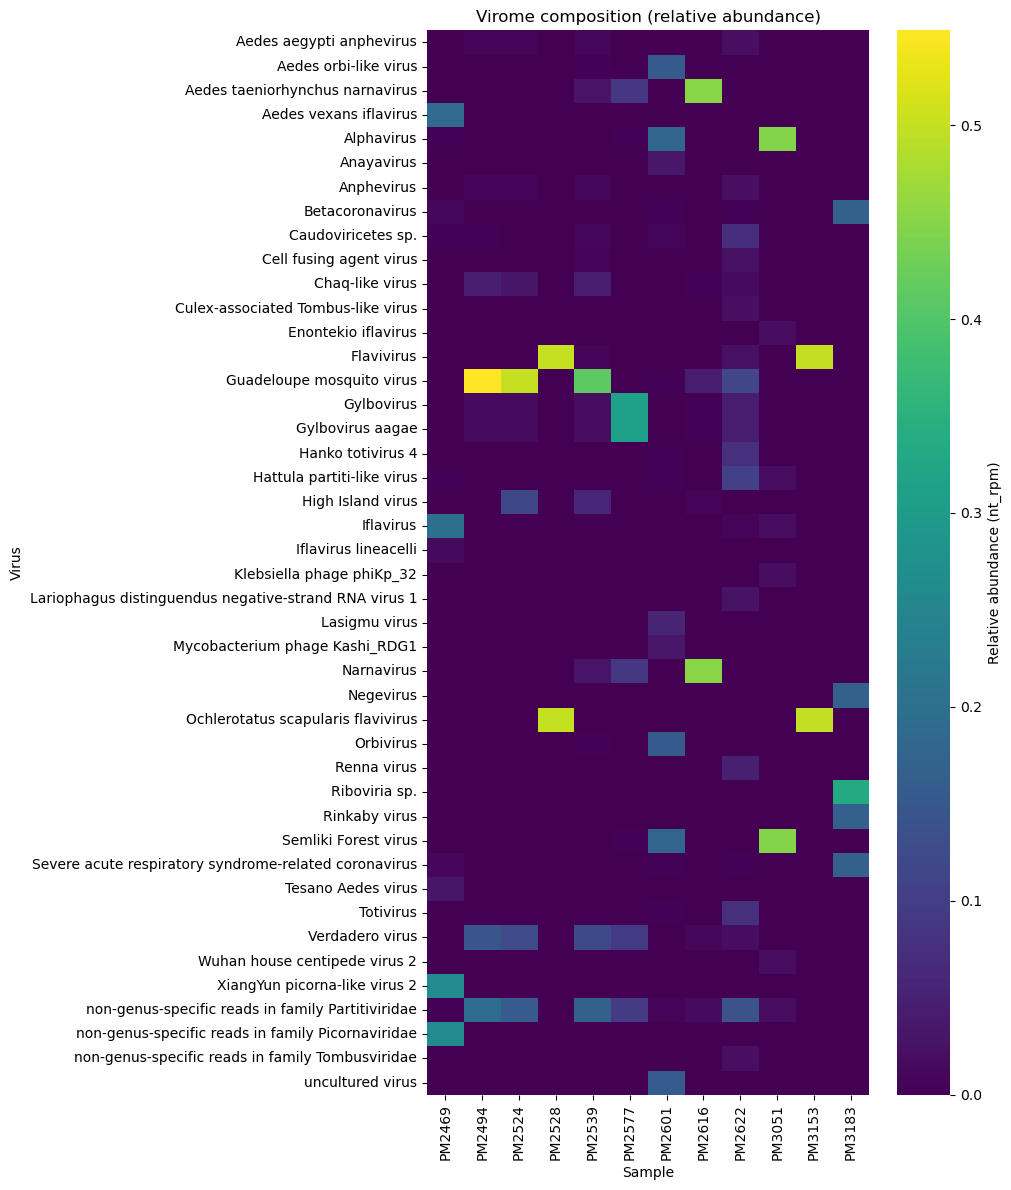

In [143]:
# Data visualization.

pivot = df_final.pivot_table(
    index="name",
    columns="sample_name", 
    values="nt_rpm",
    aggfunc="sum",
    fill_value=0
)
pivot_rel = pivot.div(pivot.sum(axis=0), axis=1)

# Low informative taxa filtering. We filter out taxa that have a relative abundance of less than 1% in all samples.
pivot_filt = pivot_rel[pivot_rel.max(axis=1) > 0.01]  # >1%

plt.figure(figsize=(10, 12))

sns.heatmap(
    pivot_filt,
    cmap="viridis",
    cbar_kws={"label": "Relative abundance (nt_rpm)"}
)

plt.title("Virome composition (relative abundance)")
plt.xlabel("Sample")
plt.ylabel("Virus")
plt.tight_layout()
plt.show()

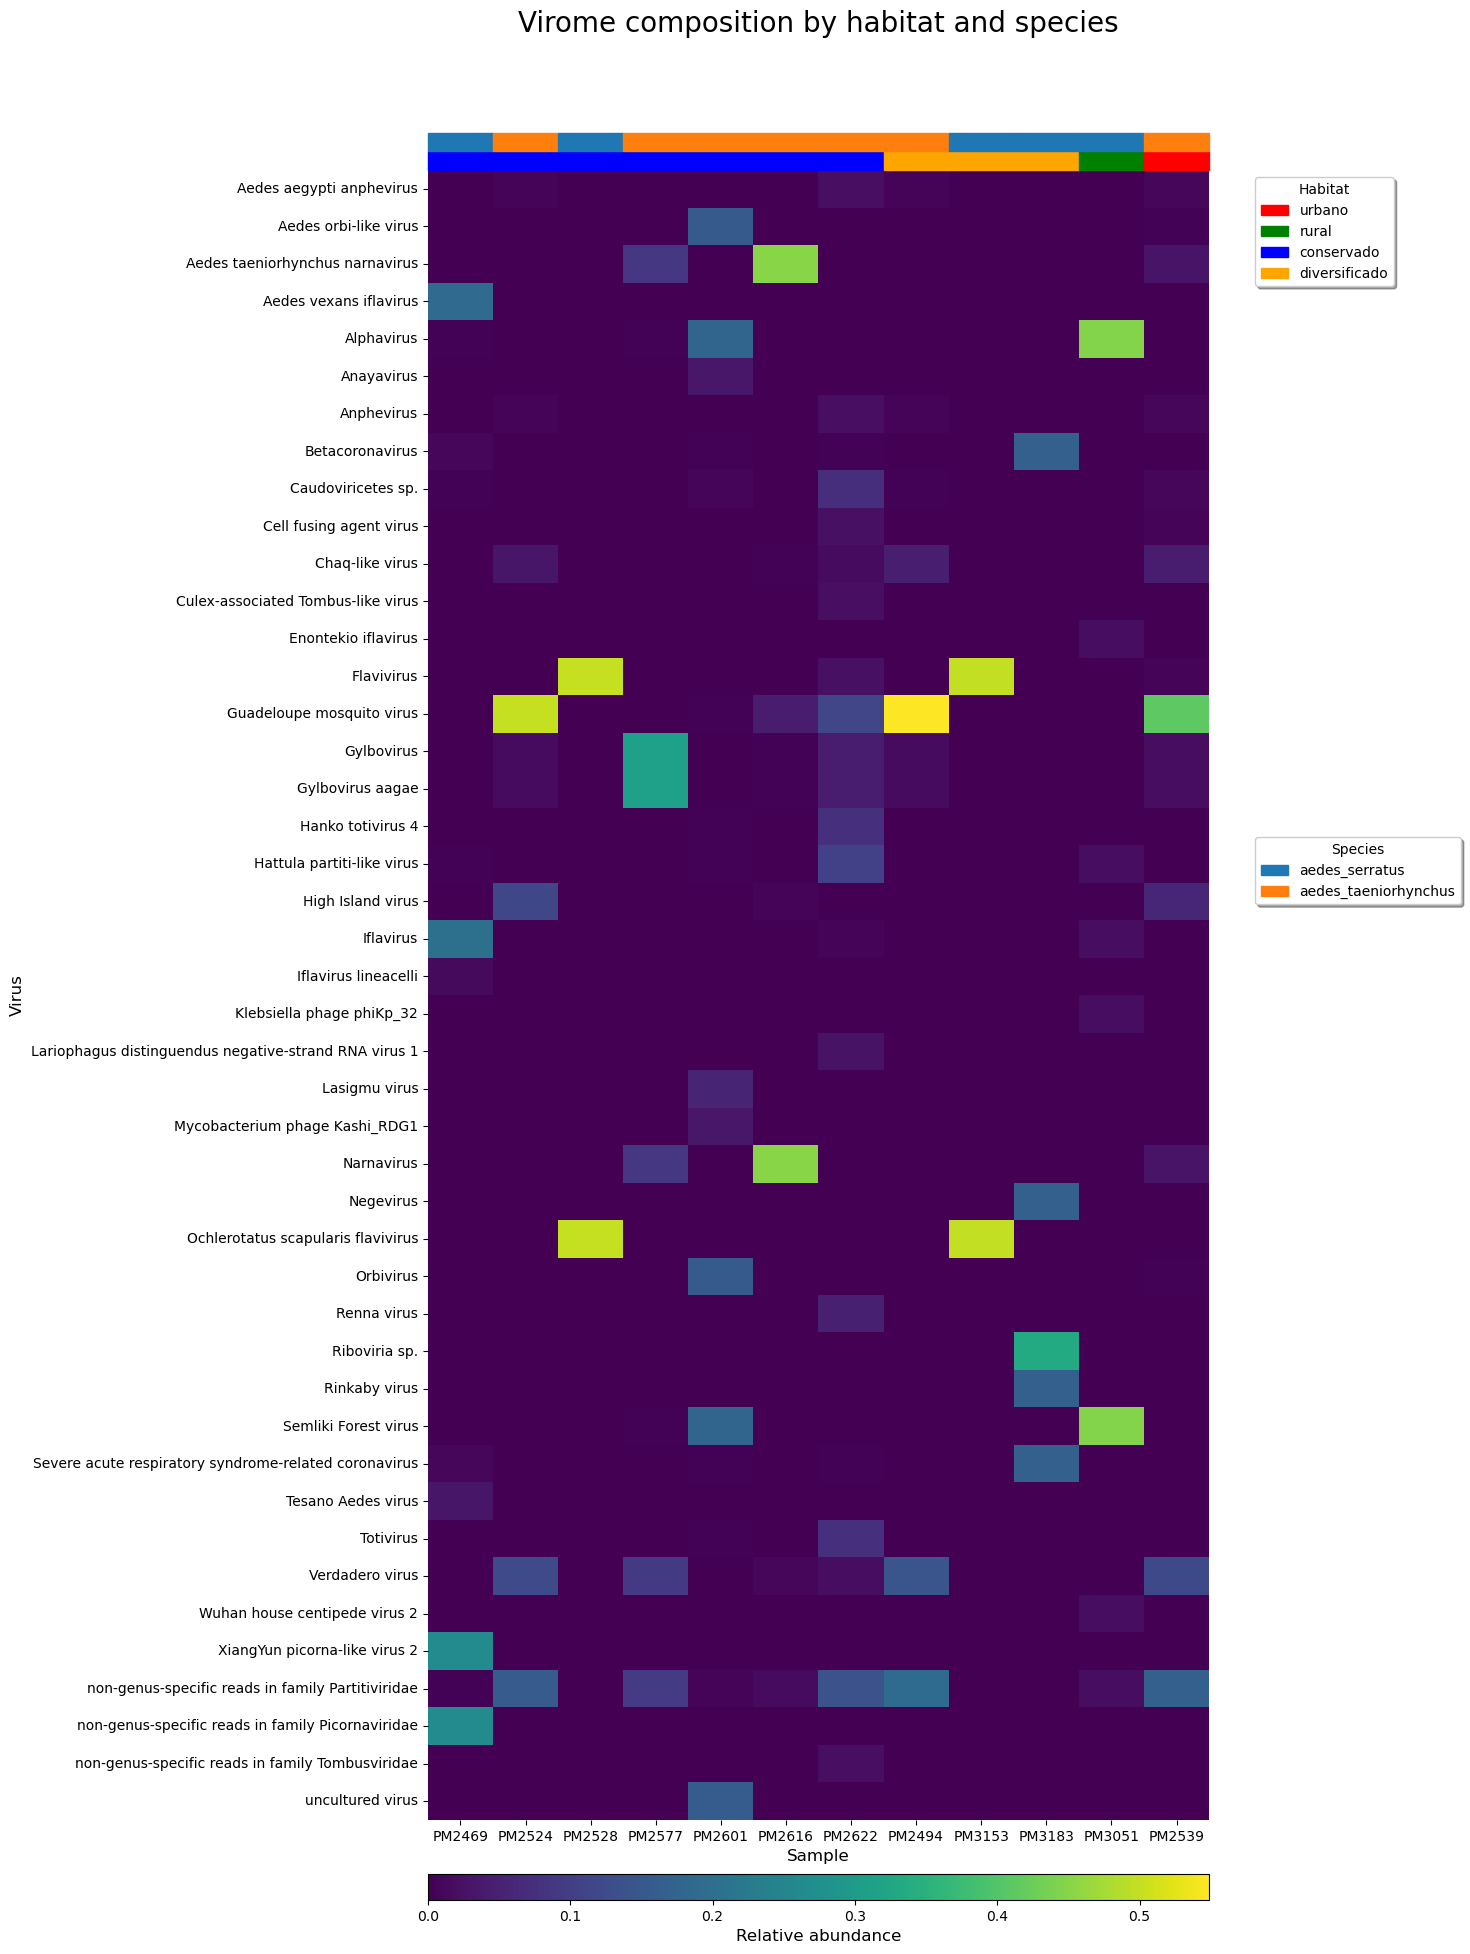

In [156]:
# Index metadata
meta = df_metadata.set_index("sample_name")

# Colors mapping
habitat_colors = meta.loc[order, "habitat"].map({
    "urbano": "red",
    "rural": "green",
    "conservado": "blue",
    "diversificado": "orange"
})

species_unique = meta["species"].unique()
palette = sns.color_palette("tab10", len(species_unique))
species_color_dict = dict(zip(species_unique, palette))
species_colors = meta.loc[order, "species"].map(species_color_dict)

# Subplots for title and heatmap
fig, (ax_title, ax_heatmap) = plt.subplots(
    2, 1, 
    figsize=(15, 20), 
    gridspec_kw={'height_ratios': [0.5, 10]}
)

# Subplot for title hidden 
ax_title.axis('off')
ax_title.set_title("Virome composition by habitat and species", fontsize=20, pad=1)

# Create heatmap without colorbar first
ax = sns.heatmap(
    pivot_ordered,
    cmap="viridis",
    cbar=False,  # Disable default colorbar
    ax=ax_heatmap
)

# Add colorbar at the bottom
cbar = fig.colorbar(ax.collections[0], ax=ax, orientation='horizontal', 
                    pad=0.03, fraction=0.05, aspect=30)
cbar.set_label("Relative abundance", fontsize=12)

# Habitat color above heatmap
for i, color in enumerate(habitat_colors):
    ax.add_patch(
        plt.Rectangle((i, -0.5), 1, 0.5, color=color, transform=ax.transData, clip_on=False)
    )

# Species color above habitat
for i, color in enumerate(species_colors):
    ax.add_patch(
        plt.Rectangle((i, -1.0), 1, 0.5, color=color, transform=ax.transData, clip_on=False)
    )

# Habitat Leyend
hab_legend = [
    mpatches.Patch(color=color, label=hab)
    for hab, color in {
        "urbano": "red",
        "rural": "green",
        "conservado": "blue",
        "diversificado": "orange"
    }.items()
]

# Species Leyend
sp_legend = [
    mpatches.Patch(color=color, label=sp)
    for sp, color in species_color_dict.items()
]

# Add both legends on the right side without overlap
legend1 = ax.legend(
    handles=hab_legend,
    title="Habitat",
    bbox_to_anchor=(1.05, 1.0),
    loc="upper left",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
)

legend2 = ax.legend(
    handles=sp_legend,
    title="Species",
    bbox_to_anchor=(1.05, 0.6),
    loc="upper left",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
)

ax.add_artist(legend1)

# Etiquetas de ejes
ax.set_xlabel("Sample", fontsize=12)
ax.set_ylabel("Virus", fontsize=12)

plt.tight_layout()
plt.show()